<a href="https://colab.research.google.com/github/corrielynnyuill-debug/Assignment15-CLY/blob/main/Assignment15_CorrieLynnYuill.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'loan-default-dataset' dataset.
Path to dataset files: /kaggle/input/loan-default-dataset
      ID  year loan_limit             Gender approv_in_adv loan_type  \
0  24890  2019         cf  Sex Not Available         nopre     type1   
1  24891  2019         cf               Male         nopre     type2   
2  24892  2019         cf               Male           pre     type1   
3  24893  2019         cf               Male         nopre     type1   
4  24894  2019         cf              Joint           pre     type1   

  loan_purpose Credit_Worthiness open_credit business_or_commercial  ...  \
0           p1                l1        nopc                  nob/c  ...   
1           p1                l1        nopc                    b/c  ...   
2           p1                l1        nopc                  nob/c  ...   
3           p4                l1        nopc                  nob/c  ...   
4           p1                l1        nopc          

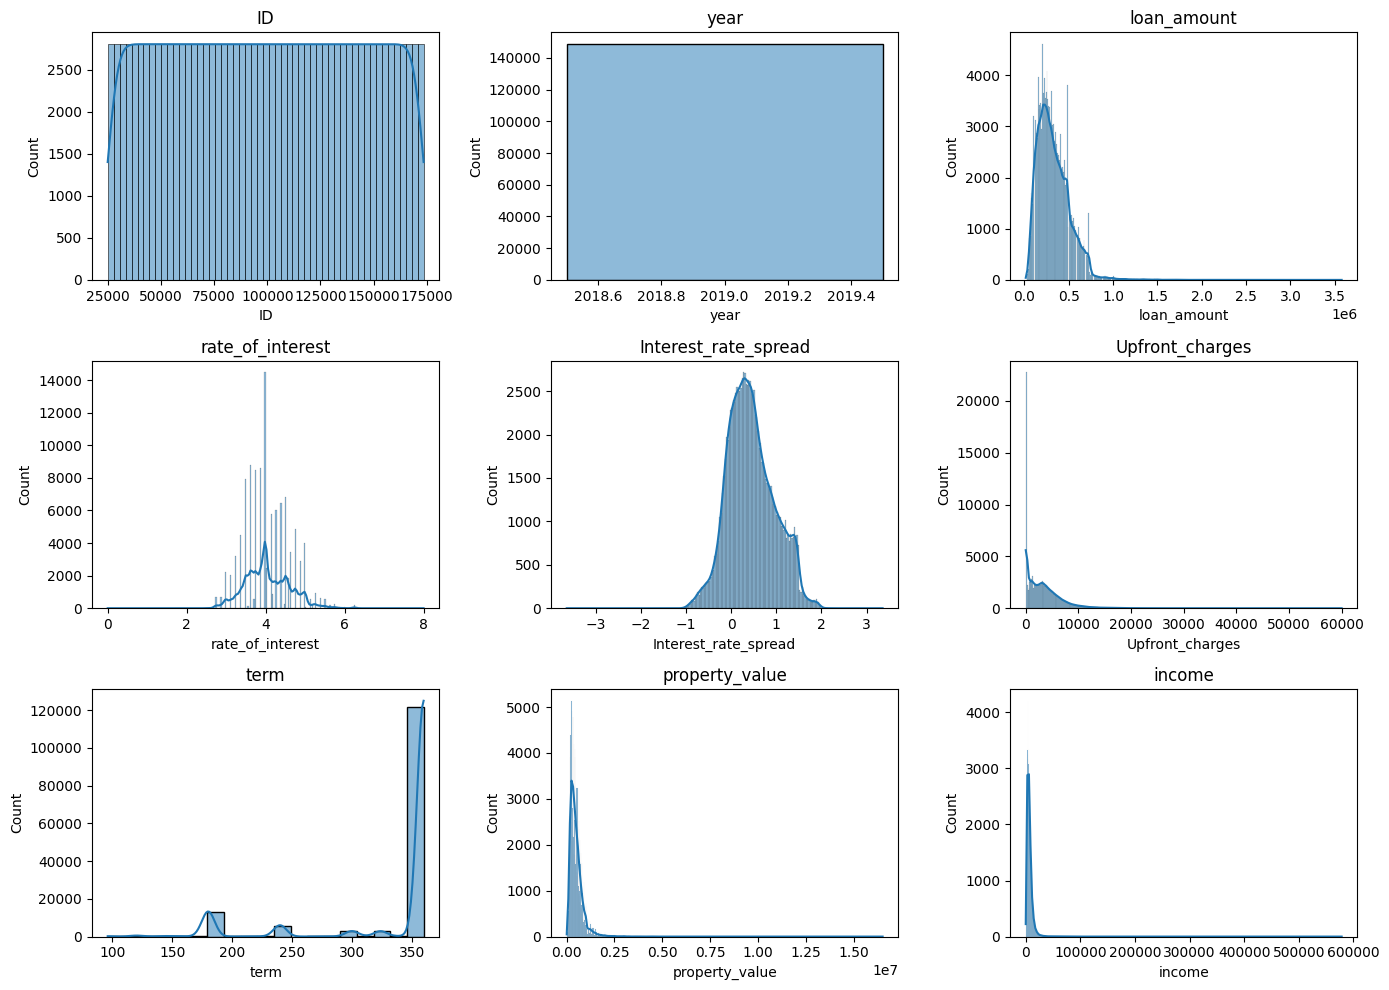

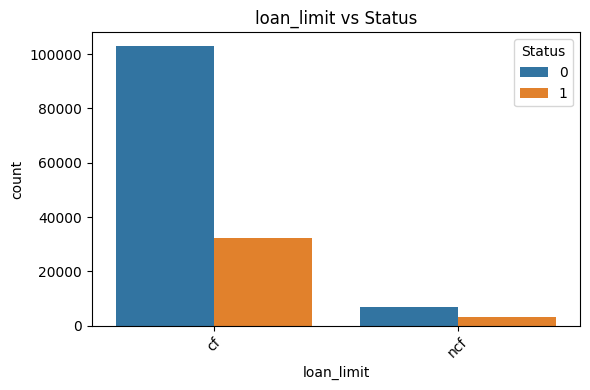

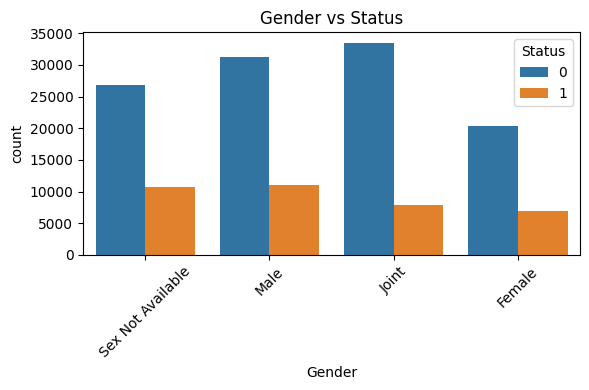

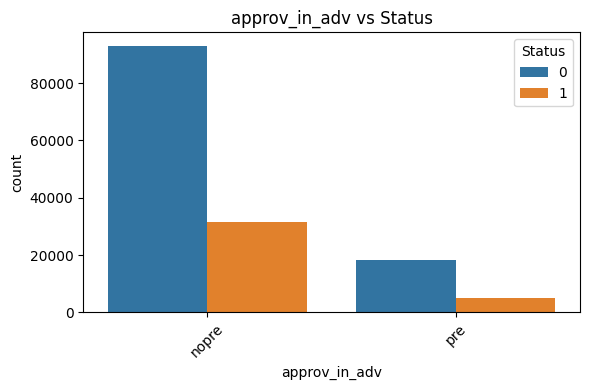

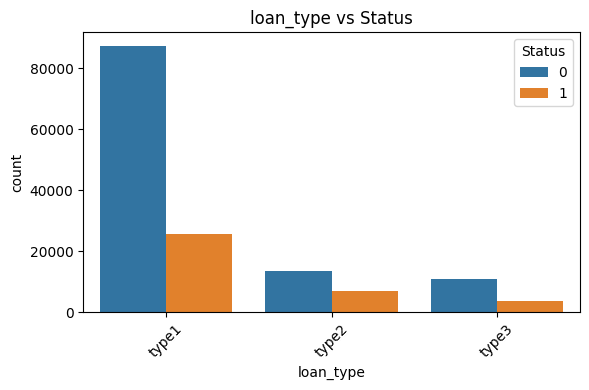

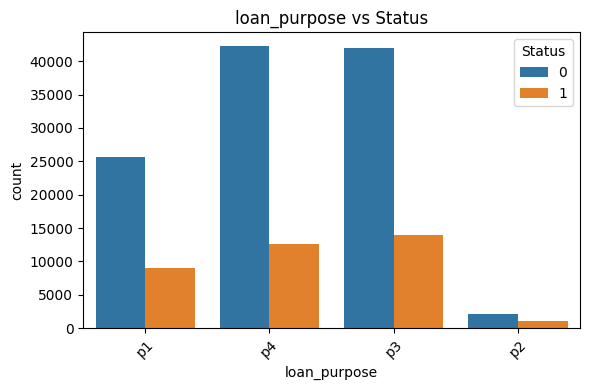

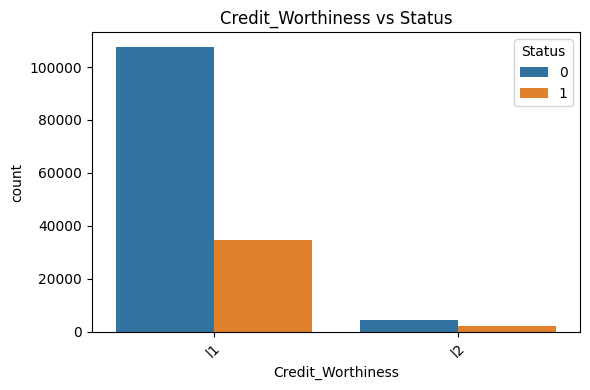

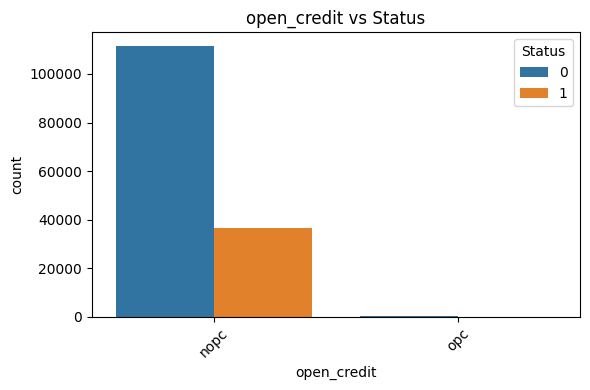

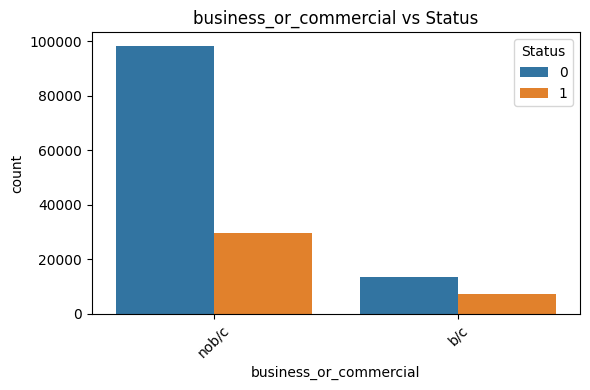

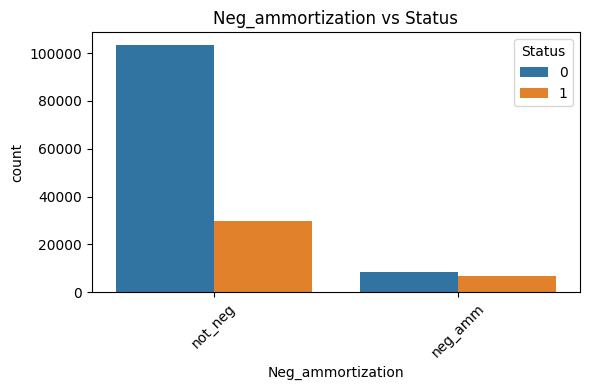

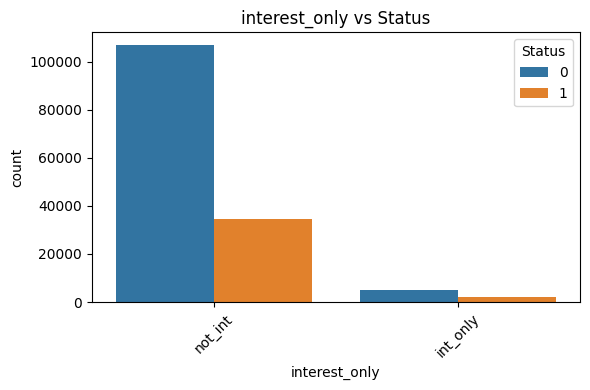

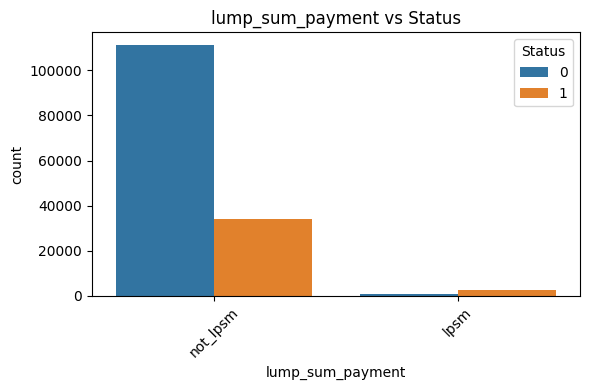

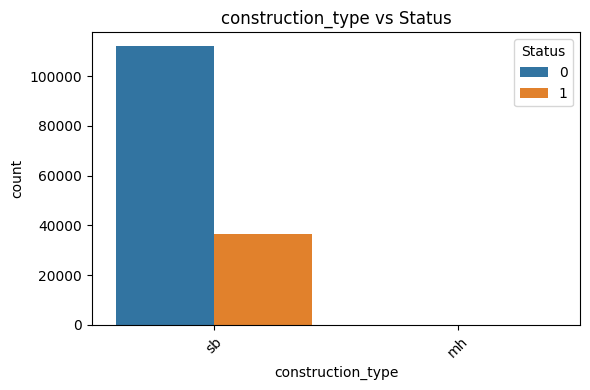

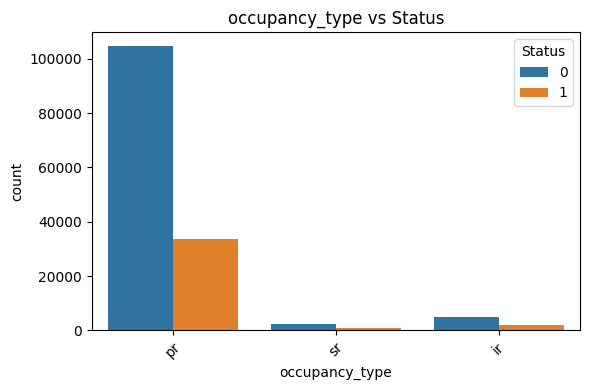

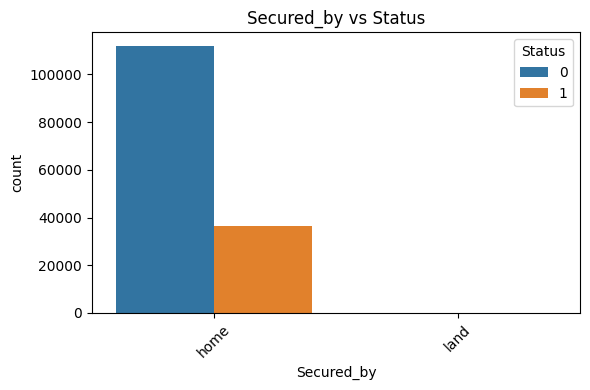

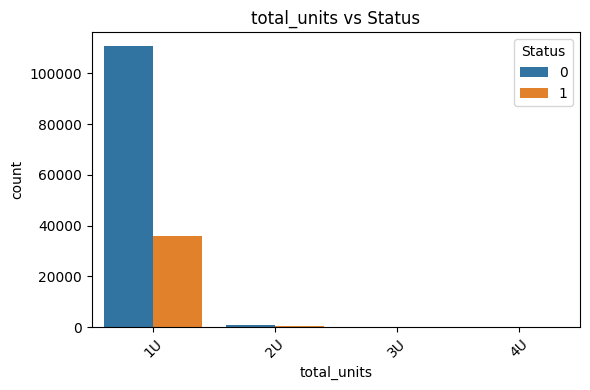

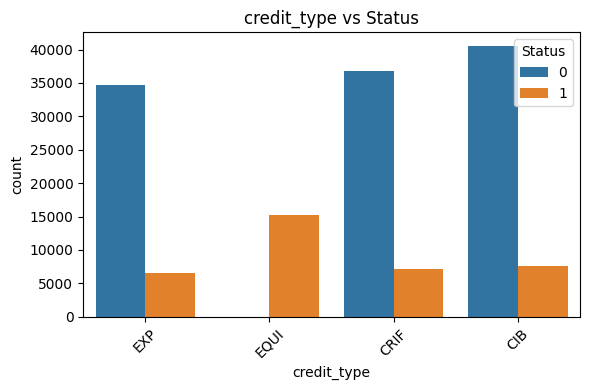

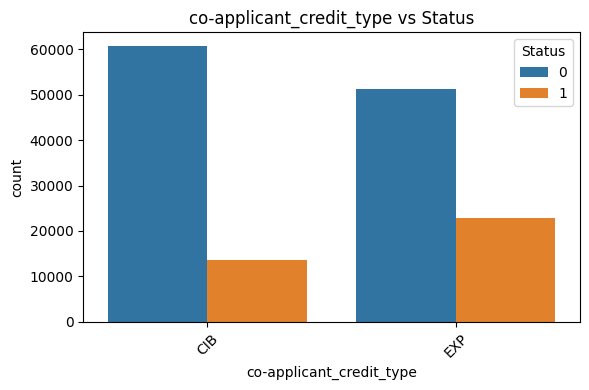

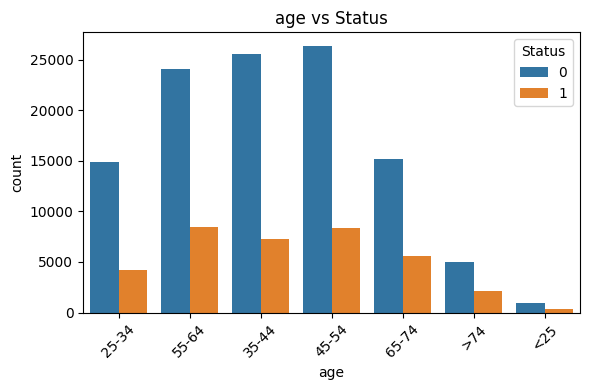

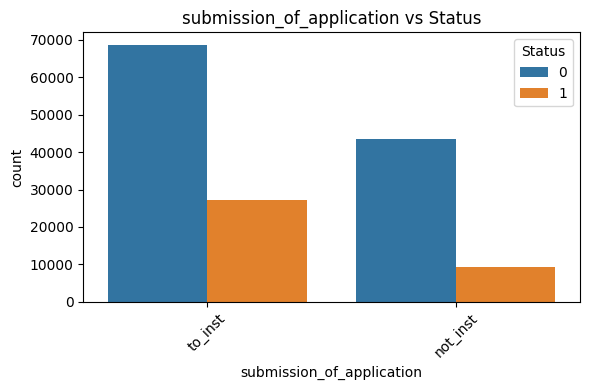

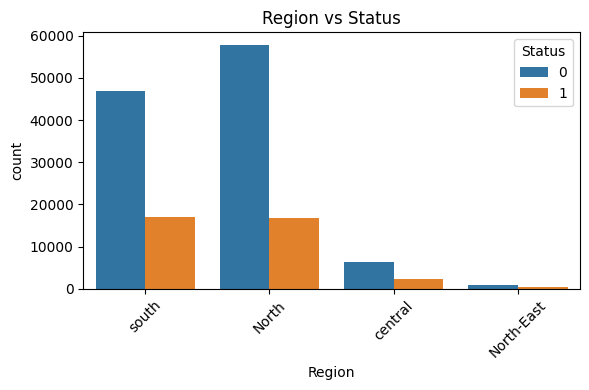

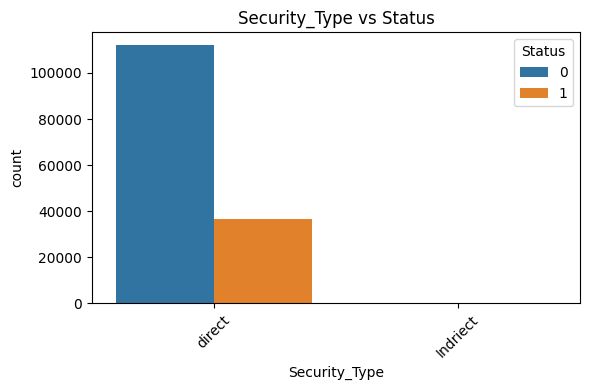

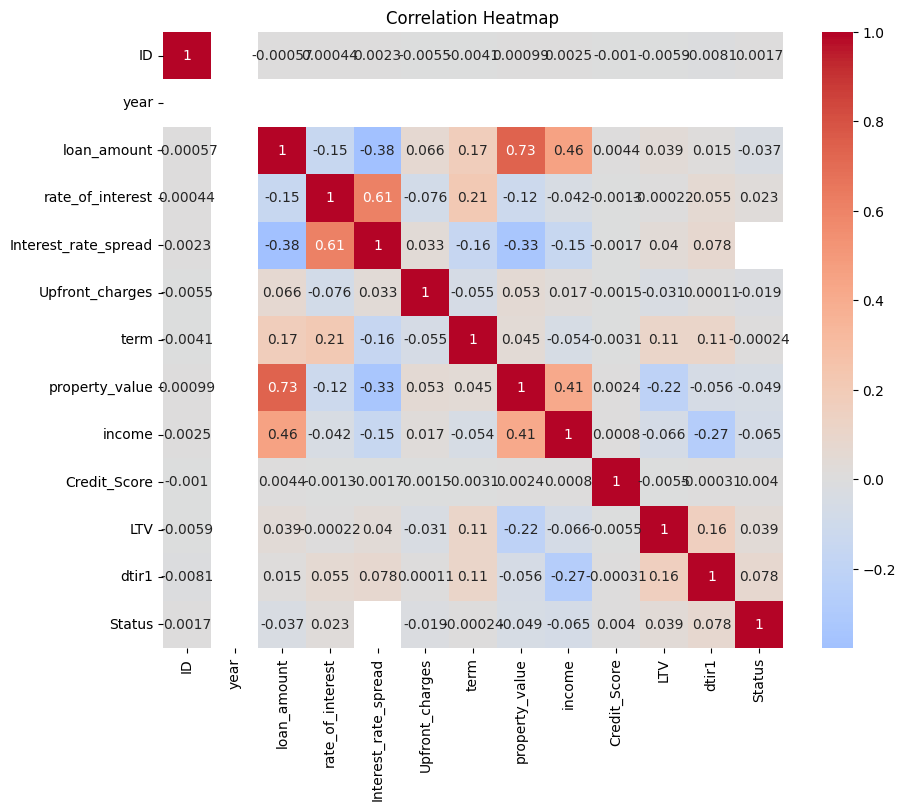

/tmp/ipykernel_71770/2763440773.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(median_val, inplace=True)
/tmp/ipykernel_71770/2763440773.py:77: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

--------------------------------------------------------------------------------
         ID  year  loan_amount  rate_of_interest  Interest_rate_spread  \
0 -1.732039   0.0    -1.166980         -0.085756             -0.086619   
1 -1.732016   0.0    -0.677607         -0.085756             -0.086619   
2 -1.731993   0.0     0.409890          1.081449             -0.513616   
3 -1.731969   0.0     0.681764          0.446653              0.565089   
4 -1.731946   0.0     1.986759         -0.065279             -0.279934   

   Upfront_charges      term  property_value    income  Credit_Score  ...  \
0        -0.164744  0.425609       -1.087010 -0.816446      0.502357  ...   
1        -0.164744  0.425609       -0.209870 -0.302164     -1.275413  ...   
2        -0.880068  0.425609        0.053272  0.412116      1.158234  ...   
3        -0.164744  0.425609        0.491841  0.793066     -0.973365  ...   
4        -1.092723  0.425609        0.784221  0.564496     -0.843916  ...   

   age_45-5

In [18]:
from kagglehub import enum
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Download dataset and load into DataFrame
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/loan-default-dataset")

print("Path to dataset files:", path)

import os
os.listdir(path)

file_path = os.path.join(path, "Loan_Default.csv")
df = pd.read_csv(file_path)

# Basic dataset Structure Analysis
print(df.head())
print('-'*80)
print(df.info())
print('-'*80)
print(df.describe())
print('-'*80)

# Exploratoty Analysis
# Define target column
target_col = 'Status'
df[target_col].value_counts(normalize=True)

# Separate numerical and catergorical columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.drop(target_col)
categorical_cols = df.select_dtypes(include=['object']).columns

# Plot numerical distributions
plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_cols[:9], 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

# Plot Target vs categorical
for col in categorical_cols:
  plt.figure(figsize=(6, 4))
  sns.countplot(data=df, x=col, hue=target_col)
  plt.title(f'{col} vs {target_col}')
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df[numeric_cols.tolist()+[target_col]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

# Handle missing values
df_clean = df.copy()

# Use median value imputation for numerical cols
for col in numeric_cols:
  median_val = df_clean[col].median()
  df_clean[col].fillna(median_val, inplace=True)

# Use mode value imputation for categorical cols
for col in categorical_cols:
  mode_val = df_clean[col].mode().iloc[0]
  df_clean[col].fillna(mode_val, inplace=True)

# Encode categorical variables
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Normalize numerical features
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

print('-'*80)
print(df_encoded.head())
print('-'*80)

In [19]:
# Feature engineering
df_engineered = df_encoded.copy()

# Debt-to-income Ratio
df_engineered['DTI'] = df_clean['loan_amount']/(df_clean['income']+1)

# Interest Burden
df_engineered['IB'] = df_clean['rate_of_interest']*df_clean['loan_amount']

# Credit score buckets
def credit_bucket(score):
  if score < 580:
    return 'Poor'
  elif score < 670:
    return 'Fair'
  elif score < 740:
    return 'Good'
  else:
    return 'Excellent'

df_engineered['credit_score_bucket'] = df_clean['Credit_Score'].apply(credit_bucket)

# Encode the new column
df_engineered = pd.get_dummies(df_engineered, columns=['credit_score_bucket'], drop_first=True)

# LTV Risk Bucket
df_engineered['ltv_risk_bucket'] = pd.cut(
    df_clean['LTV'],
    bins=[0, 60, 80, 100],
    labels=['Low', 'Medium', 'High']
)

df_engineered = pd.get_dummies(df_engineered, columns=['ltv_risk_bucket'], drop_first=True)

print(df_engineered.head())
print('-'*80)
print(df_engineered.shape)
print('-'*80)


         ID  year  loan_amount  rate_of_interest  Interest_rate_spread  \
0 -1.732039   0.0    -1.166980         -0.085756             -0.086619   
1 -1.732016   0.0    -0.677607         -0.085756             -0.086619   
2 -1.731993   0.0     0.409890          1.081449             -0.513616   
3 -1.731969   0.0     0.681764          0.446653              0.565089   
4 -1.731946   0.0     1.986759         -0.065279             -0.279934   

   Upfront_charges      term  property_value    income  Credit_Score  ...  \
0        -0.164744  0.425609       -1.087010 -0.816446      0.502357  ...   
1        -0.164744  0.425609       -0.209870 -0.302164     -1.275413  ...   
2        -0.880068  0.425609        0.053272  0.412116      1.158234  ...   
3        -0.164744  0.425609        0.491841  0.793066     -0.973365  ...   
4        -1.092723  0.425609        0.784221  0.564496     -0.843916  ...   

   Region_central  Region_south  Security_Type_direct        DTI         IB  \
0           F

Accuracy: 0.8820878455640008
--------------------------------------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.99      0.93     22406
         1.0       0.95      0.55      0.70      7328

    accuracy                           0.88     29734
   macro avg       0.91      0.77      0.81     29734
weighted avg       0.89      0.88      0.87     29734

--------------------------------------------------------------------------------
Confusion Matrix:
 [[22213   193]
 [ 3313  4015]]
--------------------------------------------------------------------------------


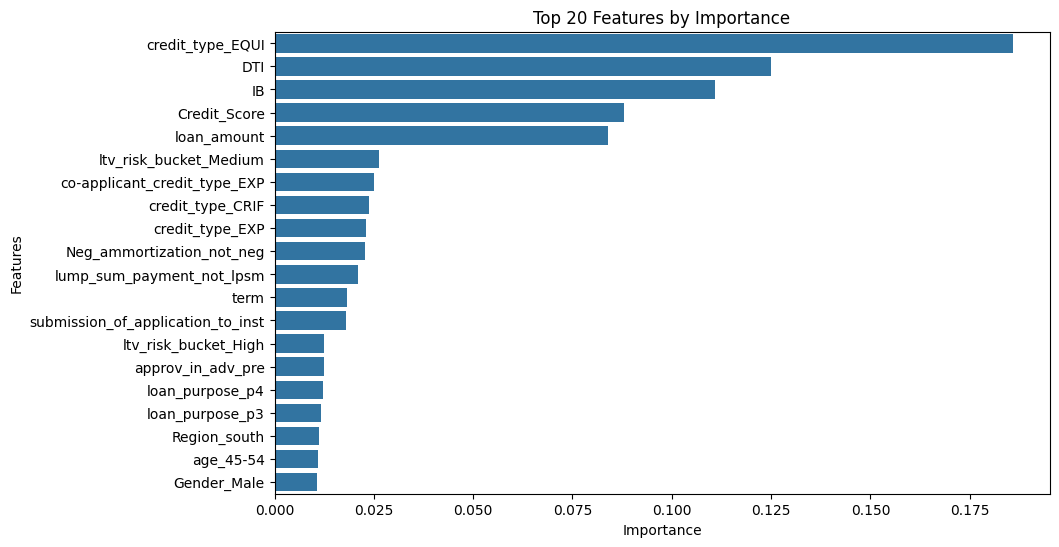

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df_model = df_engineered.copy()

# Data leak columns
leak_cols = [
    'rate_of_interest',
    'Interest_rate_spread',
    'Upfront_charges',
    'property_value',
    'LTV',
    'submission_of_application',
    'age',
    'dtir1',
    'income'
]

df_model = df_model.drop(columns=leak_cols, errors='ignore')

# Drop ID column
if 'ID' in df_model.columns:
  df_model = df_model.drop(columns=['ID'])

df_model = df_model.astype(float)
# Define X and y
X = df_model.drop(target_col, axis=1)
y = df_model[target_col]

feature_names = X.columns.tolist()
X_np = X.values

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

# Model Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluation Metrics
print('Accuracy:', accuracy_score(y_test, y_pred))
print('-'*80)
print('Classification Report:\n', classification_report(y_test, y_pred))
print('-'*80)
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('-'*80)

# Feature importance plot
importances = pd.Series(rf.feature_importances_, index=X.columns)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top20.values, y=top20.index)
plt.title('Top 20 Features by Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()


  0%|          | 0/200 [00:00<?, ?it/s]

sv shape: (200, 49)
X_test_sample shape: (200, 49)


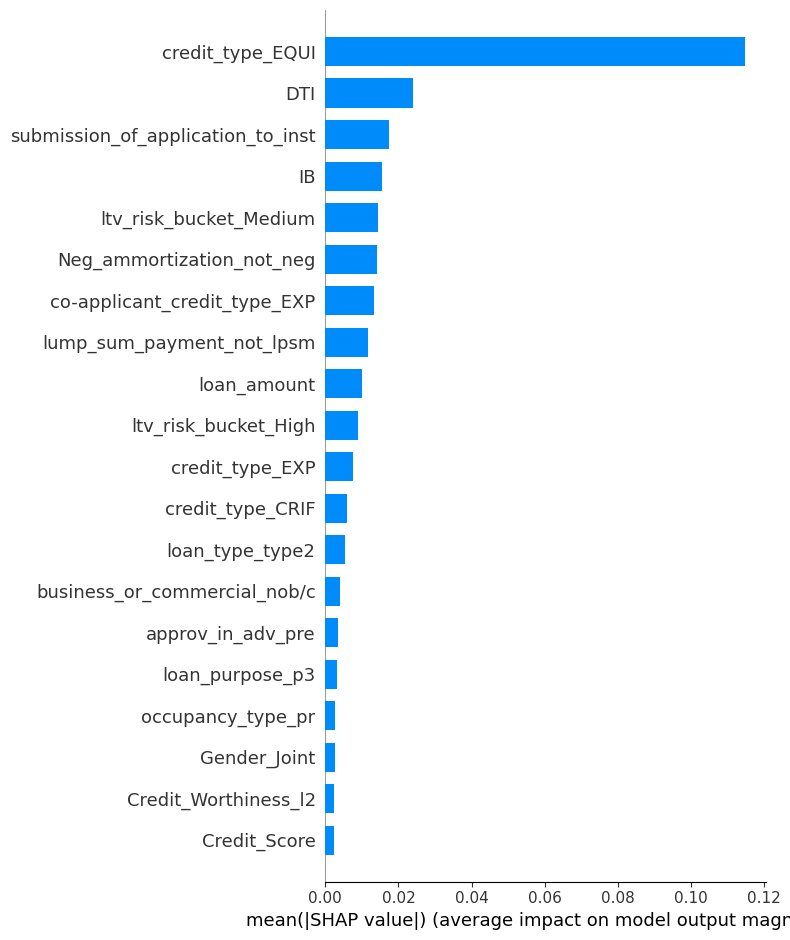

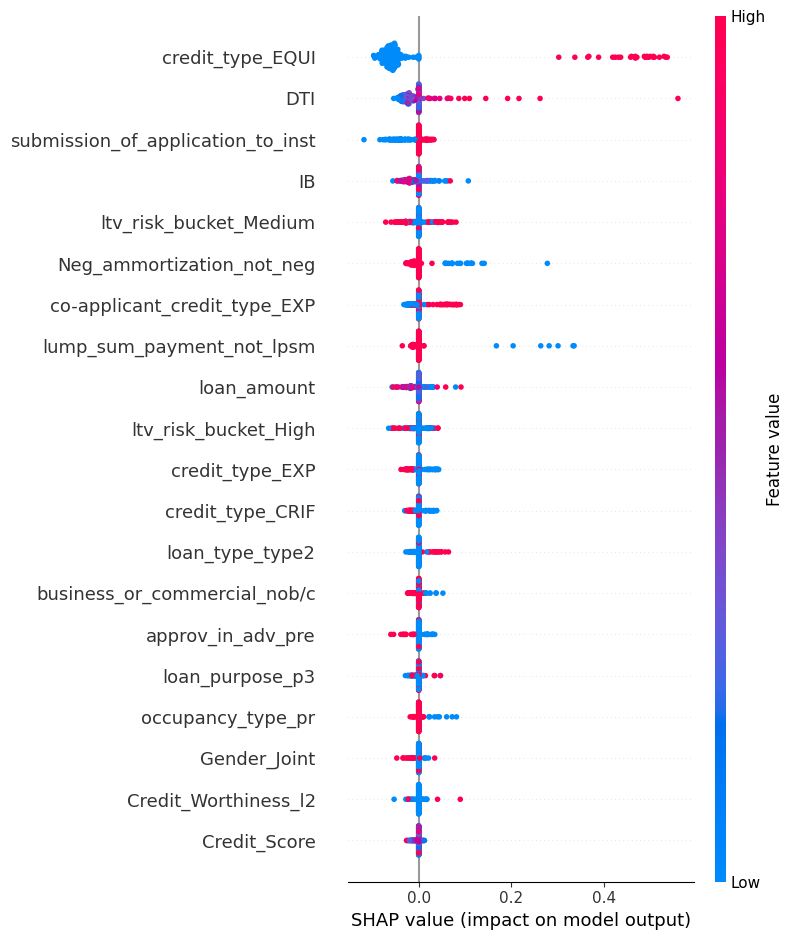

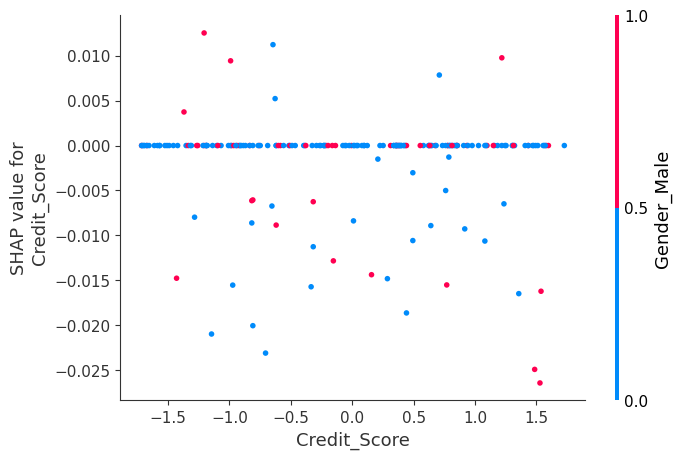

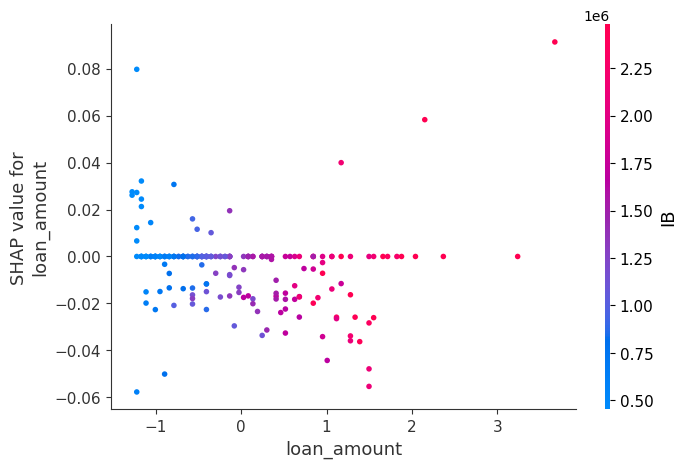

In [21]:
import shap
shap.initjs()

# KernelExplainer for RandomForest (fast)
explainer = shap.KernelExplainer(rf.predict_proba, background)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_sample, nsamples=100)

# FIX: Correctly extract SHAP values for the second class (index 1)
# The shap_values array is likely structured as (num_samples, num_features, num_classes)
sv = shap_values[:, :, 1] # Select all samples, all features, for class 1
print("sv shape:", sv.shape)
print("X_test_sample shape:", X_test_sample.shape)
# SHAP Summary bar plot
shap.summary_plot(sv, X_test_sample, plot_type="bar")

# SHAP Summary dot plot
shap.summary_plot(sv, X_test_sample, plot_type="dot")

# SHAP Dependence Plots (use sv, NOT shap_values[1])
shap.dependence_plot('Credit_Score', sv, X_test_sample)
shap.dependence_plot('loan_amount', sv, X_test_sample)

# SHAP Force plot (use sv, NOT shap_values[1])
i = 5
shap.force_plot(
    explainer.expected_value[1],
    sv[i],
    X_test_sample.iloc[i]
)
